# Multilabel Image Classification using Transfer Learning

This notebook implements a deep learning based multilabel image classification system using transfer learning with a pretrained ResNet50 architecture. The objective is to predict the presence or absence of four attributes in an image.

This solution also addresses:
- Missing attribute labels (NA values)
- Dataset imbalance across attributes
- Fine tuning of pretrained ImageNet weights

## Dataset Description

The dataset consists of:
- A folder containing input images
- A labels.txt file containing annotations for four attributes

Each attribute may take the following values:
- 1 → Attribute is present
- 0 → Attribute is absent
- NA → Attribute information is not available

This is a multilabel classification problem where each image may contain multiple attributes simultaneously.

## Handling Missing Labels (NA)

As per assignment instructions, images containing missing attribute information (NA values) are not removed.

Instead, a masking strategy is implemented:
- Known attributes are assigned a mask value of 1
- Unknown attributes are assigned a mask value of 0

During training, loss is computed only for known attributes to ensure that images with incomplete annotations are still used effectively.

## Handling Class Imbalance

The dataset is imbalanced across attributes.

To address this issue, attribute-wise class weights are computed based on the ratio of negative to positive samples.

These weights are incorporated into a custom weighted binary cross entropy loss function to ensure that rare attributes receive higher penalty when misclassified.

## Model Architecture

A pretrained ResNet50 model trained on ImageNet is used as the base feature extractor.

The pretrained network is fine-tuned for multilabel classification by replacing the final classification layer with a dense layer using sigmoid activation.

## Model Training

The model is trained using:
- Adam optimizer
- Learning rate = 1e-4
- Batch size = 32
- Masked weighted binary cross entropy loss

Early stopping is used to prevent overfitting due to limited dataset size.

In [2]:
# Mount google drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Import necessary packages and libraries

In [26]:
import pandas as pd
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense,GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import roc_auc_score
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt


In [3]:
### Loading and Preparing Label Data

#In this step, the labels.txt file is loaded and parsed to extract image names and corresponding attribute labels for each image.

df = pd.read_csv(
"/content/drive/MyDrive/Multilabel/labels.txt",
sep=" ",
keep_default_na=False
)

image_names = df.iloc[:,0].values
labels = df.iloc[:,1:].values

num_classes = labels.shape[1]

y=np.zeros((len(labels),num_classes))
mask=np.zeros((len(labels),num_classes))

for i in range(len(labels)):
    for j in range(num_classes):
        if labels[i][j]=='NA':
            y[i][j]=0
            mask[i][j]=0
        else:
            y[i][j]=int(labels[i][j])
            mask[i][j]=1

In [4]:
# Computing Class Weights for Imbalance Handling

pos=np.sum(y,axis=0)
neg=np.sum(mask,axis=0)-pos

class_weights=neg/(pos+1e-5)
print(class_weights)

[ 0.13451776  0.23983169  0.89055792 12.13432655]


### Handling Missing Attribute Information (NA)

Some images contain missing attribute values marked as NA. As per assignment instructions, these images are not removed. Instead, a masking strategy is implemented where unknown attributes are ignored during loss computation while still using the image for training.

In [5]:
#image loading and preprocessing

# Define image size

IMG_SIZE=224

## Creating empty lists to store processed images, labels and masks
X=[]
new_y=[]
new_mask=[]

## Looping through each image name from the label file
for i,name in enumerate(image_names):

    path="/content/drive/MyDrive/Multilabel/images-20260222T120306Z-1-001/images/"+name

    img=cv2.imread(path)

    # # If image is missing or corrupted, skip it
    if img is None:
        print("Skipping missing :",name)
        continue
  ## Resizing image to match model input size
    img=cv2.resize(img,(IMG_SIZE,IMG_SIZE))
    ## Normalizing pixel values between 0 and 1
    img=img/255.0
   # Appending processed image to list

    X.append(img)
    new_y.append(y[i])
    new_mask.append(mask[i]) #

# Converting lists to NumPy arrays for training
X=np.array(X)
y=np.array(new_y)
mask=np.array(new_mask)

#Converting lists to NumPy arrays for training
print("Images loaded :",X.shape)
print("Labels shape :",y.shape)
print("Mask shape :",mask.shape)



Skipping missing : image_489.jpg
Skipping missing : image_624.jpg
Skipping missing : image_875.jpg
Images loaded : (971, 224, 224, 3)
Labels shape : (971, 4)
Mask shape : (971, 4)


In [6]:
#combining label values and mask values intgo a single array
Y = np.concatenate([y,mask],axis=1)

In [7]:
# Custom loss function to handle missing labels and class imbalance
def masked_weighted_loss(y_true,y_pred):
#  Extracting actual labels from the first half of y_true
    y_label=y_true[:,:num_classes]
    y_mask=y_true[:,num_classes:]
#  Computing binary cross entropy loss
    bce=tf.keras.backend.binary_crossentropy(y_label,y_pred)
# Converting class weights to tensor
    weight=tf.constant(class_weights,dtype=tf.float32)
# Applying class weights to handle imbalance
    bce=bce*weight
    bce=bce*y_mask
# Returning normalized loss value
    return tf.reduce_sum(bce)/tf.reduce_sum(y_mask)

In [8]:
# Loading pretrained ResNet50 model with ImageNet weights
base=ResNet50(weights='imagenet',include_top=False,input_shape=(224,224,3))

for layer in base.layers:
    layer.trainable=False

x=GlobalAveragePooling2D()(base.output)
out=Dense(num_classes,activation='sigmoid')(x)

model=Model(base.input,out)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [9]:
#introduce early stopingh
early_stop = EarlyStopping(
    monitor='loss',
    patience=3,
    restore_best_weights=True
)

In [10]:
# Compile the model
model.compile(
optimizer=tf.keras.optimizers.Adam(1e-4),
loss=masked_weighted_loss
)

# TRAIN

In [11]:
# model training
model_history=model.fit(
X,
Y,
batch_size=32,
epochs=20
)

Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 21s 239ms/step - loss: 1.8814
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 1.3642
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 1.1005
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 1.0259
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.9949
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.9885
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 1.0057
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.9811
Epoch 9/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 1.0173
Epoch 10/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 1.1607
Epoch 11/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.9868
Epoch 12/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.9817
Epoch 13/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 1.0534
Epoch 14/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.9717
Epoch 15/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - loss: 0.9649
Ep

# Save model

In [12]:
#save the model
model.save("/content/drive/MyDrive/Multilabel/aimonk_multilabel_model.h5")

# Loss Curve Plot

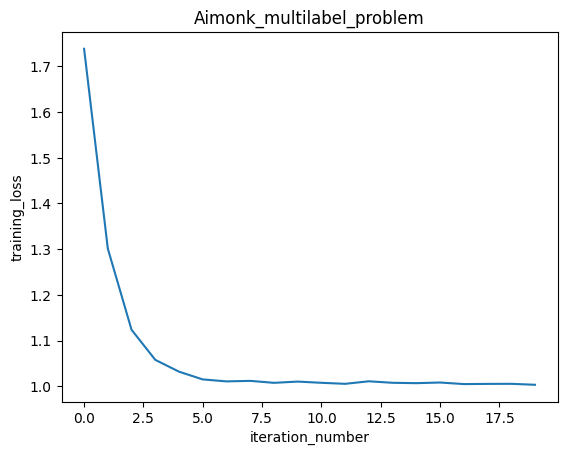

In [13]:
#Loss curve

plt.plot(model_history.history['loss'])
plt.ylabel("training_loss")
plt.xlabel("iteration_number")
plt.title("Aimonk_multilabel_problem")
plt.savefig("loss_curve.png")
plt.show()

# INFERENCE CODE

In [21]:
model=tf.keras.models.load_model(
"/content/drive/MyDrive/Multilabel/aimonk_multilabel_model.h5",
custom_objects={'masked_weighted_loss':masked_weighted_loss}
)

attribute_names = ['Attr1','Attr2','Attr3','Attr4']

def predict_image(path):

    img=cv2.imread(path)

    if img is None:
        print("Image not found")
        return

    img=cv2.resize(img,(224,224))
    img=img/255.0
    img=np.expand_dims(img,0)

    pred=model.predict(img)[0]

    attrs=[attribute_names[i] for i,v in enumerate(pred) if v>0.5]

    print("Attributes Present :",attrs)

In [22]:
predict_image("/content/drive/MyDrive/Multilabel/images-20260222T120306Z-1-001/images/image_10.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Attributes Present : ['Attr1', 'Attr2', 'Attr3']


In [23]:
#F1 score

true = Y[:,:num_classes]
mask = Y[:,num_classes:]

pred = model.predict(X)
pred_bin = (pred>0.5).astype(int)

f1 = f1_score(true[mask==1], pred_bin[mask==1])
print("Masked F1 Score :",f1)

31/31 ━━━━━━━━━━━━━━━━━━━━ 10s 196ms/step
Masked F1 Score : 0.8325591683255917


In [24]:
# auc score

auc = roc_auc_score(true[mask==1], pred[mask==1])
print("Masked AUC Score :",auc)

Masked AUC Score : 0.8483837440402427


## Additional Improvements

Due to time constraints, the following techniques were not implemented but may improve performance:
- Focal Loss for better minority class learning
- Progressive layer unfreezing
- Multilabel stratified train-validation split
- Data augmentation (rotation, flipping, brightness adjustment)
- Threshold tuning per attribute
- Mean Average Precision (mAP) evaluation